# NASA Near-Earth Asteroids Analysis and Hazardous Classification. 

## Project Goal
To analyze NASA's Near-Earth Asteroids dataset, perform thorough exploratory data analysis and cleaning, and prepare a high-quality dataset ready for machine learning modeling to predict potentially hazardous asteroids.

## Main Objective
- Explore and understand the characteristics of Near-Earth Asteroids
- Identify patterns related to potentially hazardous asteroids
- Clean and prepare the dataset for machine learning modeling
- Conduct Exploratory Data Analysis (EDA) with visualizations
- Communicate key findings and insights

## Dataset:
NASA Near-Earth Asteroids & Close Approaches (from Kaggle, originally from NASA JPL)

## Potential Challenges:
- Many columns with missing values
- Heavily imbalanced target class
- Understanding astronomical terminology

## Success Criteria:
- Clean, well-documented dataset
- Clear visualizations and actionable insights
- Professional Jupyter notebook and GitHub repository

In [56]:
# Data Loading and Initial Inspection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('near_earth_asteroids_2025.csv', low_memory=False)

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

# Initial missing values check
print("\nMissing values per column (sorted):")
print(df.isnull().sum().sort_values(ascending=False))

Dataset loaded successfully
Shape: (41281, 29)

First 5 rows:


,spkid,full_name,pdes,name,pha,H,diameter_km,diameter_m,diameter_is_estimated,size_category,...,per_y,moid_au,moid_km,moid_lunar_distances,n,condition_code,first_obs,last_obs,data_arc,data_arc_years
0,20000433,433 Eros (A898 PA),433,Eros,False,10.39,16.84000,16840.0,False,Large (>1 km) — City killer+,...,1.76,0.1480,22140485.0,57.60,0.5598,0.0,1893-10-29,2021-05-13,46582.0,127.53
1,20000719,719 Albert (A911 TB),719,Albert,False,15.59,2.70683,2706.8,True,Large (>1 km) — City killer+,...,4.28,0.2010,30069172.0,78.22,0.2302,0.0,1911-10-04,2026-03-20,41806.0,114.46
2,20000887,887 Alinda (A918 AA),887,Alinda,False,13.82,4.20000,4200.0,False,Large (>1 km) — City killer+,...,3.89,0.0797,11922950.0,31.02,0.2533,0.0,1918-02-09,2025-08-27,39281.0,107.55
3,20001036,1036 Ganymed (A924 UB),1036,Ganymed,False,9.17,37.67500,37675.0,False,Large (>1 km) — City killer+,...,4.35,0.3430,51312070.0,133.49,0.2266,0.0,1924-10-23,2026-03-22,37040.0,101.41
4,20001221,1221 Amor (1932 EA1),1221,Amor,False,17.37,1.00000,1000.0,False,Large (>1 km) — City killer+,...,2.66,0.1080,16156570.0,42.03,0.3705,0.0,1932-03-12,2025-02-19,33947.0,92.94



Missing values per column (sorted):
name                     41099
albedo                   40077
rot_per                  39100
data_arc                   406
data_arc_years             406
moid_km                    131
moid_au                    131
moid_lunar_distances       131
condition_code               2
H                            2
first_obs                    1
pha                          0
spkid                        0
class                        0
size_category                0
diameter_m                   0
diameter_is_estimated        0
diameter_km                  0
full_name                    0
pdes                         0
e                            0
per_y                        0
per                          0
ad                           0
q                            0
a                            0
i                            0
n                            0
last_obs                     0
dtype: int64


In [57]:
# Drop columns where more than 90% of data is missing
df = df.drop(columns=['name', 'albedo', 'rot_per'])

print("Columns dropped due to high missing values.")
print("Remaining missing values per column:")
print(df.isnull().sum().sort_values(ascending=False))

Columns dropped due to high missing values.
Remaining missing values per column:
data_arc                 406
data_arc_years           406
moid_km                  131
moid_au                  131
moid_lunar_distances     131
condition_code             2
H                          2
first_obs                  1
full_name                  0
spkid                      0
class                      0
size_category              0
diameter_is_estimated      0
diameter_m                 0
diameter_km                0
pha                        0
pdes                       0
e                          0
per_y                      0
per                        0
ad                         0
q                          0
a                          0
i                          0
n                          0
last_obs                   0
dtype: int64


In [58]:
# Remove any rows that still contain missing values
df = df.dropna()

print("Rows with missing values removed.")
print("New dataset shape:", df.shape)
print("Missing values left:", df.isnull().sum().sum())

Rows with missing values removed.
New dataset shape: (40742, 26)
Missing values left: 0


In [59]:
# Checking for imbalance in the target variable. The target variable is 'pha' (Potentially Hazardous Asteroid)
print("Target variable distribution:")
print(df['pha'].value_counts())

print("\nPercentage:")
print(df['pha'].value_counts(normalize=True).round(4) * 100)

Target variable distribution:
pha
False    38203
True      2539
Name: count, dtype: int64

Percentage:
pha
False    93.77
True      6.23
Name: proportion, dtype: float64


In [60]:
# Check for impossible or suspicious values
print("Diameter (km) min/max:", df['diameter_km'].min(), df['diameter_km'].max())
print("MOID (AU) min/max:", df['moid_au'].min(), df['moid_au'].max())
print("Eccentricity min/max:", df['e'].min(), df['e'].max())
print("Absolute magnitude H min/max:", df['H'].min(), df['H'].max())

# Check for zero or negative diameters
print("\nAsteroids with diameter_km <= 0:", (df['diameter_km'] <= 0).sum())

# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Diameter (km) min/max: 0.0009129793677462 37.675
MOID (AU) min/max: 4.54e-07 0.708
Eccentricity min/max: 0.0028 0.9964
Absolute magnitude H min/max: 9.17 32.95

Asteroids with diameter_km <= 0: 0
Number of duplicate rows: 0


In [61]:
# Start looking at summary statistics

print("=== Numerical Features Summary ===")
display(df.describe())

print("\n=== Categorical Features Summary ===")
display(df.describe(include='str'))

# Value counts for key categorical columns
print("\nOrbit Class Distribution:")
print(df['class'].value_counts())

=== Numerical Features Summary ===


,spkid,H,diameter_km,diameter_m,e,a,i,q,ad,per,per_y,moid_au,moid_km,moid_lunar_distances,n,condition_code,data_arc,data_arc_years
count,4.074200e+04,40742.000000,40742.000000,40742.000000,40742.000000,40742.000000,40742.000000,40742.000000,40742.000000,4.074200e+04,40742.000000,4.074200e+04,4.074200e+04,40742.000000,40742.000000,40742.000000,40742.000000,40742.000000
mean,2.843672e+07,23.659815,0.167436,167.433037,0.434117,1.754508,11.873518,0.915020,2.593992,9.560965e+02,2.617955,8.287206e-02,1.239748e+07,32.251299,0.529971,5.224903,1409.013966,3.857719
std,2.426461e+07,2.833311,0.405987,405.988101,0.176909,2.010194,10.560935,0.222079,4.001222,1.231075e+04,33.777900,9.653336e-02,1.444119e+07,37.567878,0.284421,3.170836,3103.040435,8.495631
min,3.002856e+06,9.170000,0.000913,0.900000,0.002800,0.461800,0.010000,0.069000,0.650000,1.150000e+02,0.314000,4.540000e-07,6.800000e+01,0.000000,0.000150,0.000000,1.000000,0.000000
25%,3.745033e+06,21.630000,0.025613,25.600000,0.300100,1.287250,4.380000,0.793250,1.650000,5.340000e+02,1.460000,1.200000e-02,1.795174e+06,4.670000,0.309200,2.000000,6.000000,0.020000
50%,2.045784e+07,24.000000,0.056294,56.300000,0.448100,1.681000,8.430000,0.963000,2.410000,7.960000e+02,2.180000,4.310000e-02,6.447668e+06,16.770000,0.452150,7.000000,22.000000,0.060000
75%,5.433118e+07,25.710000,0.168446,168.400000,0.562775,2.166000,16.620000,1.058000,3.340000,1.160000e+03,3.190000,1.220000e-01,1.825094e+07,47.480000,0.674675,8.000000,901.500000,2.467500
max,5.460683e+07,32.950000,37.675000,37675.000000,0.996400,350.300000,165.600000,1.300000,699.320000,2.390000e+06,6560.000000,7.080000e-01,1.059153e+08,275.530000,3.141000,9.000000,46582.000000,127.530000



=== Categorical Features Summary ===


,full_name,pdes,size_category,class,first_obs,last_obs
count,40742,40742,40742,40742,40742,40742
unique,40742,40742,4,4,7763,6144
top,433 Eros (A898 PA),433,Small (25-140m) — Local damage,APO,2014-04-23,2026-03-22
freq,1,1,19077,23062,73,115



Orbit Class Distribution:
class
APO    23062
AMO    14343
ATE     3299
IEO       38
Name: count, dtype: int64


In [62]:
# Compare key features between PHA's and non-PHA's
comparision = df.groupby('pha')[['diameter_km', 'H', 'moid_au', 'e', 'a', 'i']].agg(['mean', 'median', 'min', 'max'])
display(comparision)

diameter_km                                      H                       \
             mean    median       min     max       mean median    min    max   
pha                                                                             
False    0.151041  0.051105  0.000913  37.675  23.885413  24.21   9.17  32.95   
True     0.414120  0.274449  0.076000   7.000  20.265349  20.59  14.08  22.57   

        moid_au          ...       e                 a                         \
           mean  median  ...     min     max      mean median     min     max   
pha                      ...                                                    
False  0.086806  0.0489  ...  0.0028  0.9964  1.750247  1.673  0.4618  350.30   
True   0.023687  0.0234  ...  0.0122  0.9670  1.818608  1.804  0.6310   17.81   

               i                      
            mean median   min    max  
pha                                   
False  11.701265   8.32  0.01  165.6  
True   14.465325  10.30  0.15  134.0  

[2 rows x 24 columns]

## Key Insights from Summary Statistics

After exploring the basic statistics of the cleaned Near-Earth Asteroid dataset, a clear story begins to emerge.

### Most Near-Earth Asteroids are small and relatively harmless
The vast majority of the 40,742 asteroids in this dataset are small. The median diameter is only about 50 meters, and even the average stays well under 1 km. Only a small fraction reach sizes capable of causing regional or global damage.

### Getting close to Earth’s orbit is surprisingly common
More than half of all asteroids in the dataset have a Minimum Orbit Intersection Distance (MOID) below the 0.05 AU threshold used in the official definition of a Potentially Hazardous Asteroid. In other words, many asteroids *geometrically* come close to Earth’s path. However, closeness alone is not enough to make them dangerous.

### What actually makes an asteroid “Potentially Hazardous”?
When we directly compare PHAs versus non-PHAs, two factors stand out dramatically:

- **Size**: Potentially Hazardous Asteroids are significantly larger (median diameter ~274 m vs ~51 m for non-PHAs).
- **Proximity**: PHAs have much smaller MOIDs (median 0.023 AU vs 0.049 AU).

Absolute magnitude (H) strongly supports the size difference — PHAs are noticeably brighter on average, which is expected for larger objects.

Orbital shape (eccentricity) and inclination show only minor differences and do not appear to be strong predictors on their own.

### Orbit Class Distribution
Apollo (APO) asteroids dominate the dataset (over 56%), followed by Amor (AMO). These Earth-approaching and Earth-crossing populations are exactly where we would expect most hazardous objects to be found.

### Bottom line so far
Being labeled a Potentially Hazardous Asteroid is relatively rare (only 6.2% of the dataset). The combination of **sufficient size** and **sufficiently close orbital approach** is what separates the dangerous minority from the much larger population of small, distant, or poorly timed objects.

These insights give us a strong foundation for the next stage: visual exploration and, perhaps eventually, building a machine learning model in the future that can identify any truly hazardous asteroids.

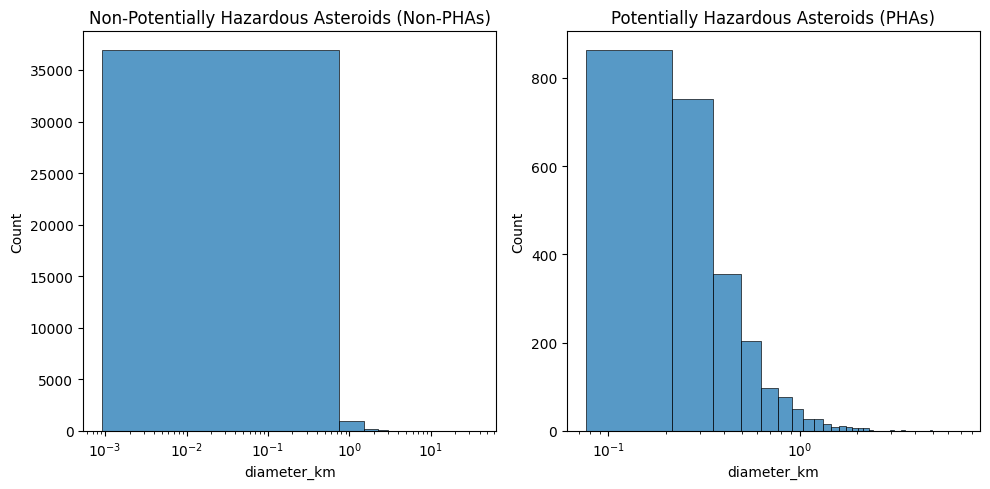

In [63]:
# Visualization 1: Asteroid Size Distribution by PHA Status
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df[df['pha'] == False], x='diameter_km', bins=50)
plt.title('Non-Potentially Hazardous Asteroids (Non-PHAs)')
plt.xscale('log')

plt.subplot(1, 2, 2)
sns.histplot(data=df[df['pha'] == True], x='diameter_km', bins=50)
plt.title('Potentially Hazardous Asteroids (PHAs)')
plt.xscale('log')

plt.tight_layout()
plt.show()


## Interpretation of Size Distribution
The histograms show a clear seperation in size distribution between the two groups.

**Non-PHA Asteroids** (left) are heavily right-skewed. This confirms that the vast majority of the near-Earth asteroids being tracked by NASA JPL are small (less than 1km in diameter). The tail to the right indicates a small amount of larger asteroids but still not big enough to be considered potentially hazardous, even if they were to approach Earth closely.

**PHA Asteroids** (right) are also right-skewed but it also shows a distribution shift towards larger asteroids. This confirms that there are a lot more medium-to-large asteroids in this group, which strongly supports the official definition of Potentially Hazardous Asteroids in regards to size. 

**Key takeaways**: Size is one of the most important factors that seperate hazardous from non-hazardous asteroids.

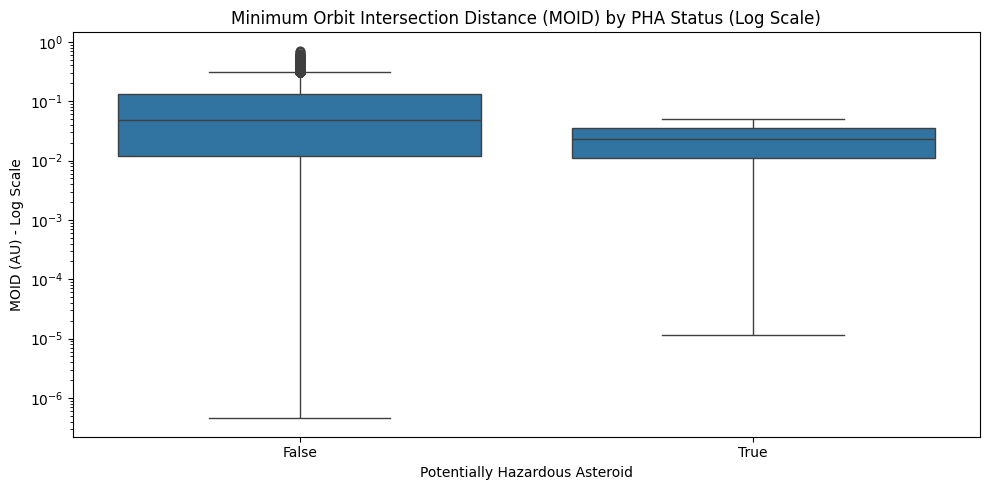

In [64]:
# Comparing MOID of PHA's to non-PHAs
plt.figure(figsize=(10, 5))
sns.boxplot(x='pha', y='moid_au', data=df)
plt.yscale('log')
plt.title('Minimum Orbit Intersection Distance (MOID) by PHA Status (Log Scale)')
plt.ylabel('MOID (AU) - Log Scale')
plt.xlabel('Potentially Hazardous Asteroid')
 
plt.tight_layout()
plt.show()

## Interperetation of MOID Comparison
The boxplot shows a clear separation between the two groups.

Potentially Hazardous Asteroids, marked as True, have much lower Minimum Orbit Intersection Distances than non-hazardous ones.

This confirms that orbital proximity is an important factor in the official PHA definition. While many non-PHAs still come relatively close to Earth's orbit, the hazardous group is concentrated at the lowest MOID values.

In other words, for an asteroid to be classified as Potentially Hazardous, it generally needs a small enough MOID value, which means a close orbital approach to Earth, plus sufficient size.

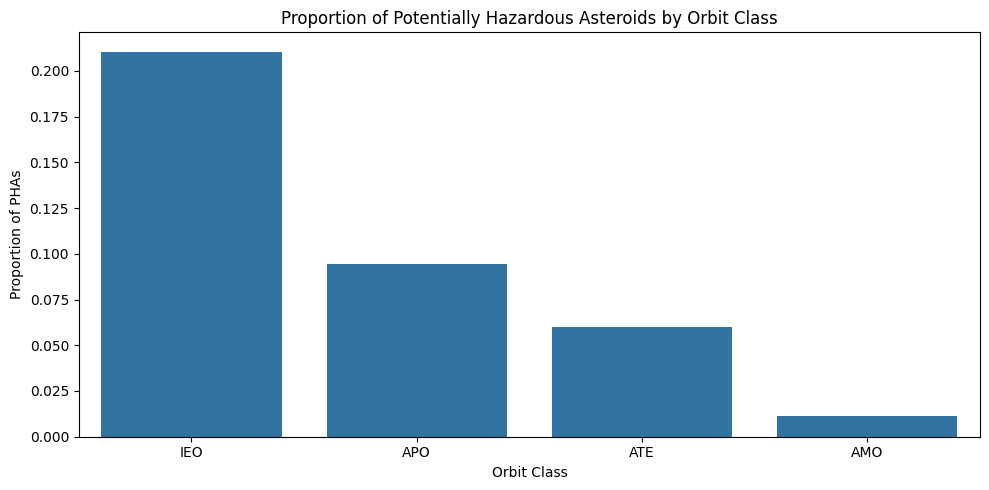

       count   sum    mean
class                     
AMO    14343   159  0.0111
APO    23062  2174  0.0943
ATE     3299   198  0.0600
IEO       38     8  0.2105


In [65]:
# PHA rate by orbit class
pha_rate = df.groupby('class')['pha'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=pha_rate.index, y=pha_rate.values)
plt.title('Proportion of Potentially Hazardous Asteroids by Orbit Class')
plt.ylabel('Proportion of PHAs')
plt.xlabel('Orbit Class')
plt.tight_layout()
plt.show()

# Showing the actual counts
print(df.groupby('class')['pha'].agg(['count', 'sum', 'mean']).round(4))

## Interpretation of PHA Rate by Oribit Class
The bar chart and table show the proportion of Potentially Hazardous Asteroids within each orbit class. 

- **Apollo (APO)** asteroids are the most common overall, but only about 10% of them are classified as PHAs.
- **IEO (Atira)** asteroids - which have orbits entirely inside Earth's orbit- have the highest PHA rate (approximately 20%). Even though they are rare, a much larger proportion of them are potentially hazardous.
-  **Aten (ATE)** and **Amor (AMO)** asteroids have much lower PHA proportions.

The key takeaway here is that while Apollo asteroids dominate the dataset, IEO class asteroids show the highest risk ratio. This could suggest that asteroids with orbits completely inside Earth's path can still pose a significant threat when they are large enough.

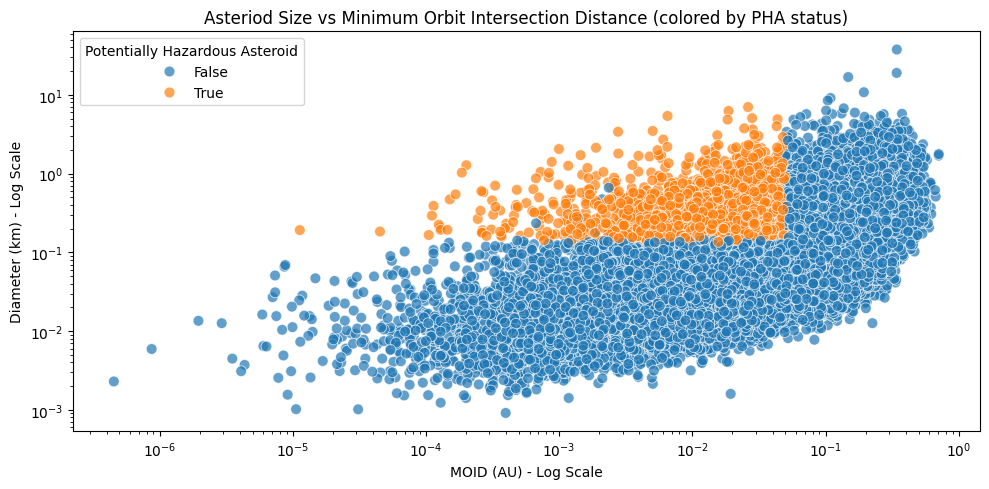

In [66]:
# Diameter vs MOID coloured by PHA status
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x='moid_au',
    y='diameter_km',
    hue='pha',
    alpha=0.7,
    s=60
)
plt.xscale('log')
plt.yscale('log')
plt.title('Asteriod Size vs Minimum Orbit Intersection Distance (colored by PHA status)')
plt.xlabel('MOID (AU) - Log Scale')
plt.ylabel('Diameter (km) - Log Scale')
plt.legend(title='Potentially Hazardous Asteroid')
plt.tight_layout()
plt.show()

## Asteroid Size vs Minimum Orbit Intersection Distance
This scatterplot shows us the two main criteria used to classify Potentially Hazardous Asteroids. 

- Most of the non-PHA asteroids (Blue) are clustered in the lower-right area. This shows that non_PHAs have a small size and larger MOID.
- The orange cluster, which is concentrated in the upper-left region, shows us asteroids with larger diameters with smaller MOID values.

The orange cluster indicates a clear "danger zone" where larger asteroids with close orbital approaches are more likely to be labeled as potentially hazardous. We can also see a distinct separation between the two groups, especially when size and MOID are considered together. 

**Key takeaway**: In order for an asteroid to be considered potentially hazardous, both size and proximity have to be considered. This plot provides strong visual support for the official definition used by NASA.

### Checking for Redundant Features

Looking at the data dictionary in the README, we can see that there are a few columns that appear to measure the same thing in different units:
- 'moid_au', 'moid_km', and 'moid_lunar_distances'
- 'per' and 'per_y'
- 'data_arc' and 'data_arc_years'
- 'diameter_km' and 'diameter_m'

We can confirm this with a correlation check and a heatmap, before dropping redundant features.

In [67]:
# Ccorrelation check for suspected redundent columns
print("1. MOID columns correlation:")
print(df[['moid_au', 'moid_km', 'moid_lunar_distances']].corr())

print("\n2. Orbital Period columns correlation:")
print(df[['per', 'per_y']].corr())

print("\n3. Data Arc columns correlation:")
print(df[['data_arc', 'data_arc_years']].corr())

print("\n4. Diameter columns correlation:")
print(df[['diameter_km', 'diameter_m']].corr())

1. MOID columns correlation:
                      moid_au  moid_km  moid_lunar_distances
moid_au                   1.0      1.0                   1.0
moid_km                   1.0      1.0                   1.0
moid_lunar_distances      1.0      1.0                   1.0

2. Orbital Period columns correlation:
            per     per_y
per    1.000000  0.999999
per_y  0.999999  1.000000

3. Data Arc columns correlation:
                data_arc  data_arc_years
data_arc             1.0             1.0
data_arc_years       1.0             1.0

4. Diameter columns correlation:
             diameter_km  diameter_m
diameter_km          1.0         1.0
diameter_m           1.0         1.0


In [69]:
# Dropping redundant features

df = df.drop(columns=[
    'moid_km',
    'moid_lunar_distances',
    'per',
    'data_arc',
    'diameter_m'
])

print("Redundant columns dropped.")
print("New shape of the dataset:", df.shape)
print(df.columns)

Redundant columns dropped.
New shape of the dataset: (40742, 21)
Index(['spkid', 'full_name', 'pdes', 'pha', 'H', 'diameter_km',
       'diameter_is_estimated', 'size_category', 'class', 'e', 'a', 'i', 'q',
       'ad', 'per_y', 'moid_au', 'n', 'condition_code', 'first_obs',
       'last_obs', 'data_arc_years'],
      dtype='str')


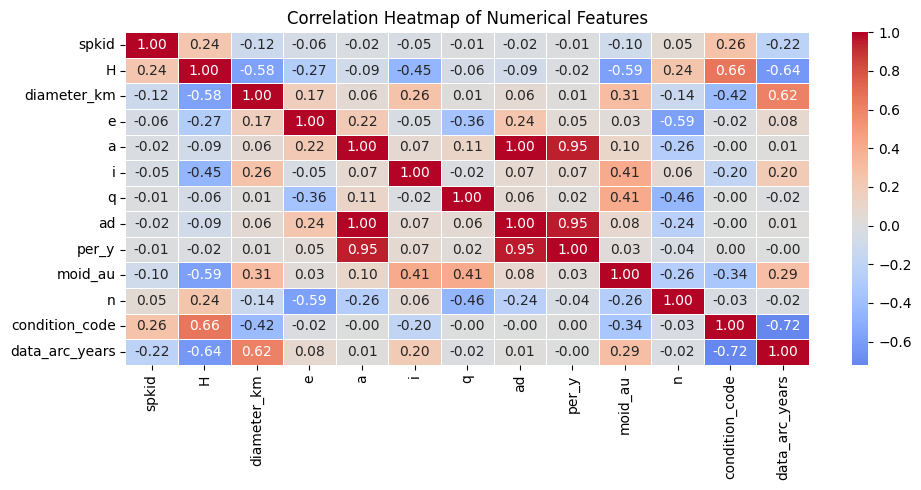

In [70]:
# Correlation heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

## Correlation Heatmap Insights
The heatmap shows the correlation between the numerical features in the dataset.

**Key Observations:**
- Asteroid size ('diameter_km') and orbital closeness ('moid_au') have a weak-to-moderate positive correlation of 0.31.
- Absolute magnitude ('H') has a moderate negative correlation with both 'diameter_km' (-0.58) and 'moid_au' (-0.59).
- There is a moderatley strong correlation between 'H' and 'condition_code' (0.66), indicating that brighter asteroids tend to have better-determined orbits.
- 'data_arc_years' shows some correlation with size-related features, which can be attributed to larger and brighter objects being easier to observe over longer periods of time.

**Overall takeaway**:
Size and orbital intersection distance appear to be the most relevant numerical features related to whether an asteroid is potentially hazardous.